## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [4]:
df = pd.read_csv(r"C:\Users\parih\Downloads\amazon_sales.csv")

In [5]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


## Check how many columns

In [8]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

df.shape

## Missing value check 

In [10]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

## Statistical Analysis of Data

In [11]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


## Check for duplicate columns

In [12]:
df.duplicated().sum()

np.int64(0)

## For removing/ delete duplicates

In [13]:
df.drop_duplicates(inplace=True)

## Selction of  outlier column which column has numeric or float values

In [25]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['order_id', 'product_id', 'price', 'discount_percent', 'quantity_sold',
       'rating', 'review_count', 'discounted_price', 'total_revenue'],
      dtype='object')

## Detection of outliers by the IQR methods

In [26]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

In [21]:
IQR


order_id            24999.5000
product_id           2006.0000
price                 248.4950
discount_percent       15.0000
quantity_sold           2.0000
rating                  2.0000
review_count          249.0000
discounted_price      213.0225
total_revenue         728.6500
dtype: float64

In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

## Total lower bound

In [22]:
lower_bound


order_id           -24998.50000
product_id          -1026.00000
price                -244.90250
discount_percent      -17.50000
quantity_sold          -1.00000
rating                 -1.00000
review_count         -248.50000
discounted_price     -209.85375
total_revenue        -852.65500
dtype: float64

## Total upper bound 

In [23]:
upper_bound

order_id            74999.50000
product_id           6998.00000
price                 749.07750
discount_percent       42.50000
quantity_sold           7.00000
rating                  7.00000
review_count          747.50000
discounted_price      642.23625
total_revenue        2061.94500
dtype: float64

In [27]:
outliers = df[(df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)].sum()
outliers

order_id                  0.0
order_date                  0
product_id                0.0
product_category            0
price                     0.0
discount_percent          0.0
quantity_sold             0.0
customer_region             0
payment_method              0
rating                    0.0
review_count              0.0
discounted_price          0.0
total_revenue       1668232.0
dtype: object

## Total outliers rows

In [35]:
print("Total outlier rows:", outliers)

Total outlier rows: order_id                  0.0
order_date                  0
product_id                0.0
product_category            0
price                     0.0
discount_percent          0.0
quantity_sold             0.0
customer_region             0
payment_method              0
rating                    0.0
review_count              0.0
discounted_price          0.0
total_revenue       1668232.0
dtype: object


## Box plot of all columms

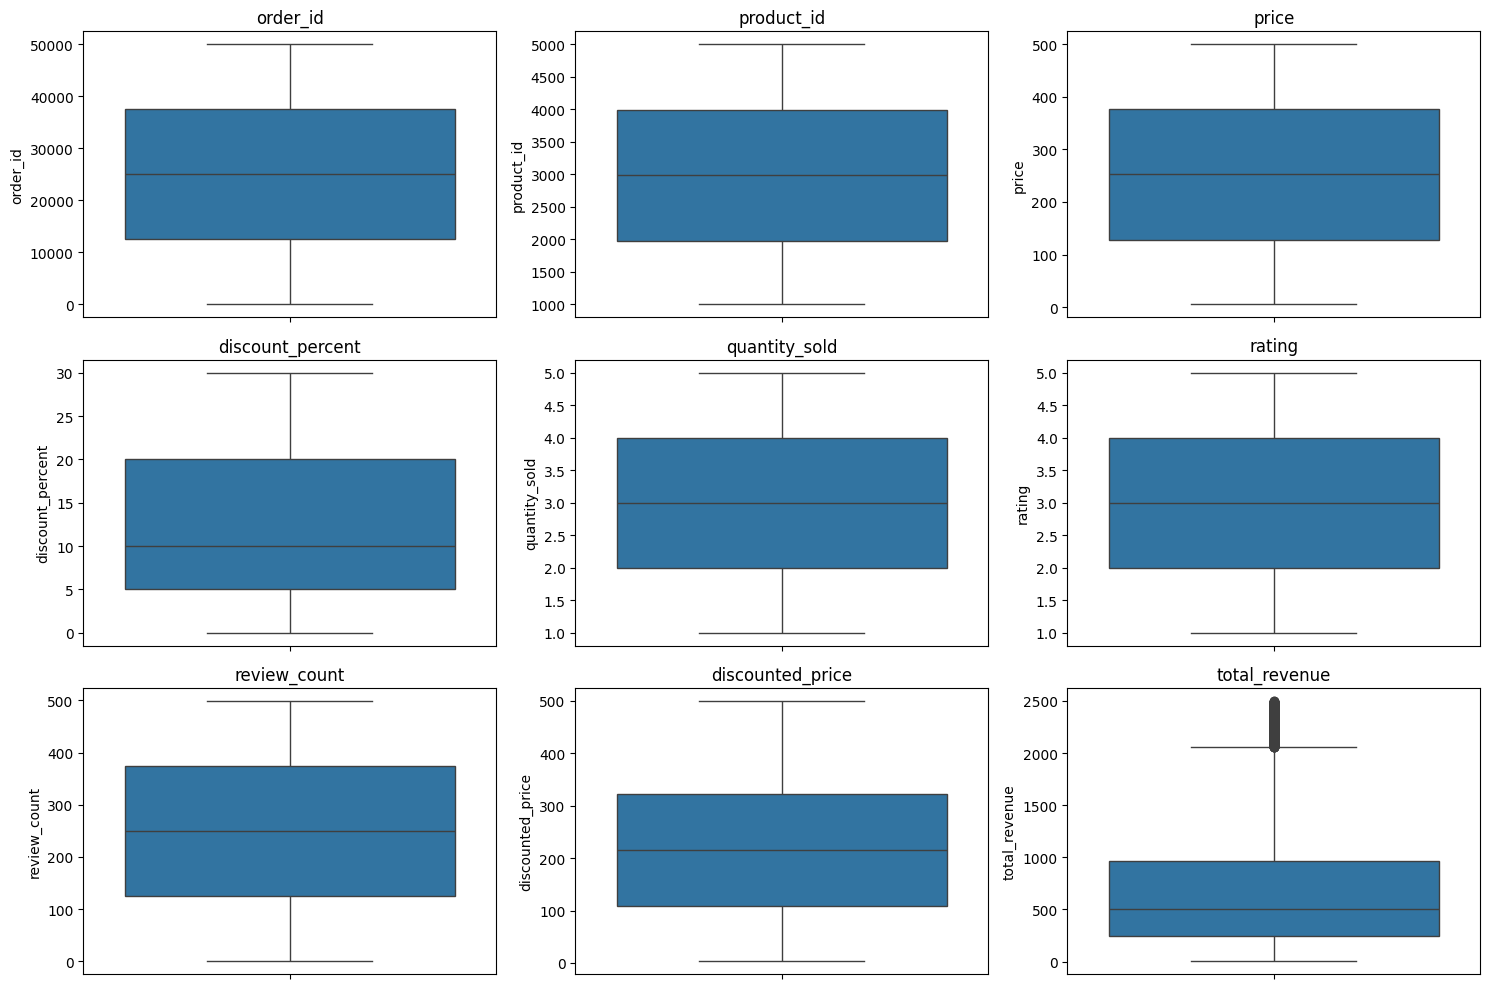

In [36]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
The boxplot of total revenue shows several extreme values above the normal range. These outliers represent high-value transactions, possibly due to expensive products or bulk purchases.

## Box plot of only total revenue column

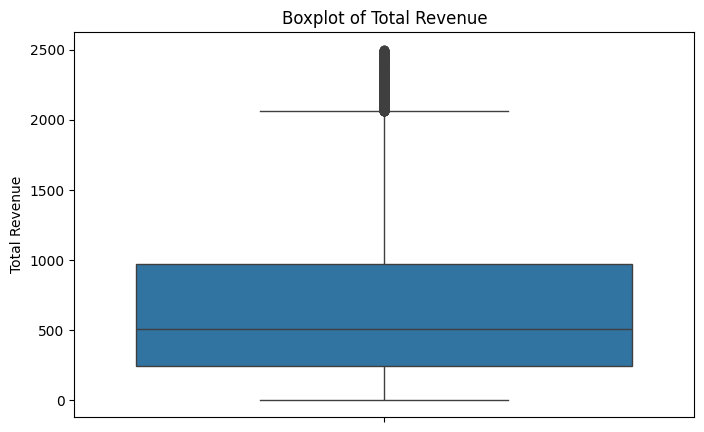

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['total_revenue'])

plt.title("Boxplot of Total Revenue")
plt.ylabel("Total Revenue")

plt.show()

## Identify the exact outlier rows

In [40]:
Q1 = df['total_revenue'].quantile(0.25)
Q3 = df['total_revenue'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_revenue'] < lower) | (df['total_revenue'] > upper)]

outliers.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
204,205,2023-01-21,1256,Home & Kitchen,469.04,5,5,North America,UPI,1.8,87,445.59,2227.95
216,217,2022-08-13,2764,Electronics,483.28,0,5,Asia,UPI,2.4,190,483.28,2416.40
291,292,2022-04-14,1917,Books,489.42,5,5,Asia,Debit Card,2.2,494,464.95,2324.75
300,301,2023-12-07,2959,Books,490.29,5,5,Middle East,UPI,1.9,429,465.78,2328.90
466,467,2022-03-10,2000,Home & Kitchen,443.64,5,5,North America,Wallet,1.3,166,421.46,2107.30


## Total outliers

In [41]:
len(outliers)

752

In [43]:
df_clean = df[(df['total_revenue'] >= lower) & (df['total_revenue'] <= upper)]

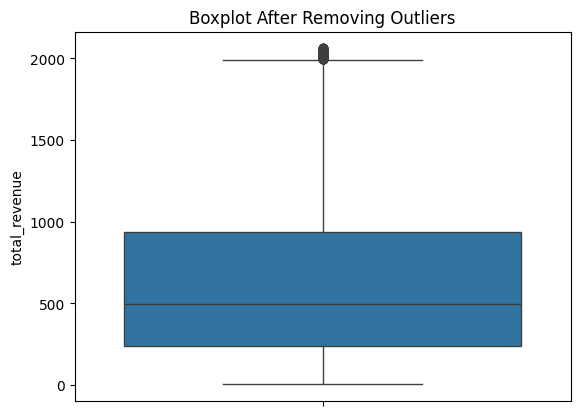

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df_clean['total_revenue'])
plt.title("Boxplot After Removing Outliers")
plt.show()

In [ ]:
After removing outliers, the distribution of total revenue becomes more balanced. This helps improve the reliability of further analysis and modeling.

## After cleaning outliers of total data 

In [45]:
df_clean.shape

(49248, 13)

## After cleaning Statistical analysis of data

In [46]:
df_clean.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,49248.000000,49248.000000,49248.000000,49248.000000,49248.000000,49248.000000,49248.000000,49248.000000,49248.000000
mean,24992.935815,2987.218912,249.254307,13.474456,2.968852,2.995604,249.367893,215.454067,633.494593
std,14438.132616,1155.914295,141.621397,9.848885,1.404244,1.154271,144.261129,125.163644,493.113345
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12488.750000,1984.000000,126.032500,5.000000,2.000000,2.000000,125.000000,107.860000,236.607500
50%,24993.500000,2983.000000,249.050000,15.000000,3.000000,3.000000,250.000000,212.575000,493.245000
75%,37485.250000,3989.000000,371.200000,20.000000,4.000000,4.000000,374.000000,318.022500,939.515000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.890000,2061.900000


## Plot distribution of Total Revenue Distribution

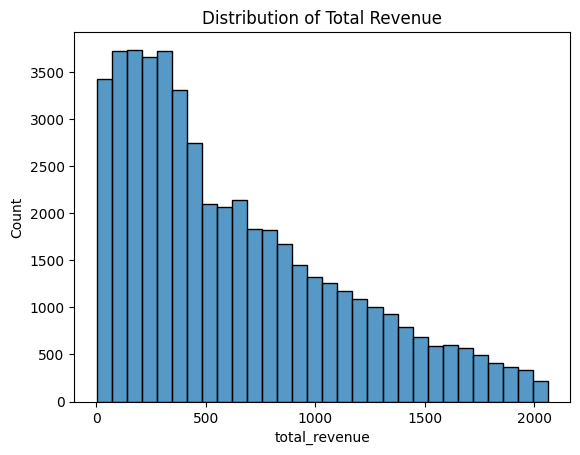

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean['total_revenue'], bins=30)
plt.title("Distribution of Total Revenue")
plt.show()

# A histogram was plotted to visualize the distribution of total revenue. The graph shows how revenue values are spread across orders. Most orders fall within the middle revenue range, while very high revenue transactions occur less frequently.



In [ ]:
From the histogram:
Most orders generate moderate revenue values, while very high revenue orders are rare. This indicates that customers typically purchase moderately priced products rather than high-value bulk orders.

## Corelation Analysis show relationship between numerical variables

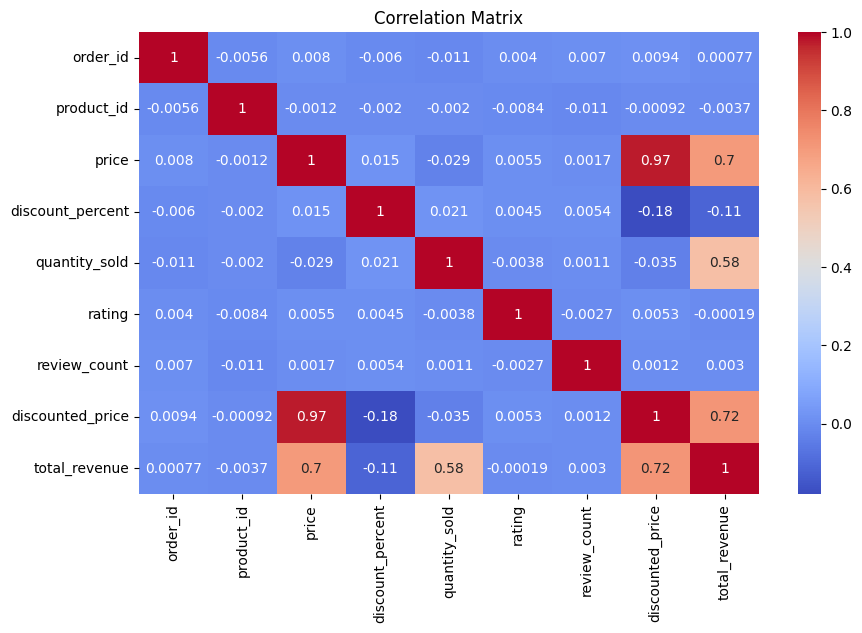

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# A correlation heatmap was created to analyze the relationship between numerical variables. The results show that total revenue has a strong positive correlation with discounted price and quantity sold.

In [ ]:
From the correlation heatmap:
Total revenue shows strong positive correlation with discounted price and quantity sold. This indicates that both product price and sales volume significantly influence revenue generation.

## Category-wise Sales Analysis

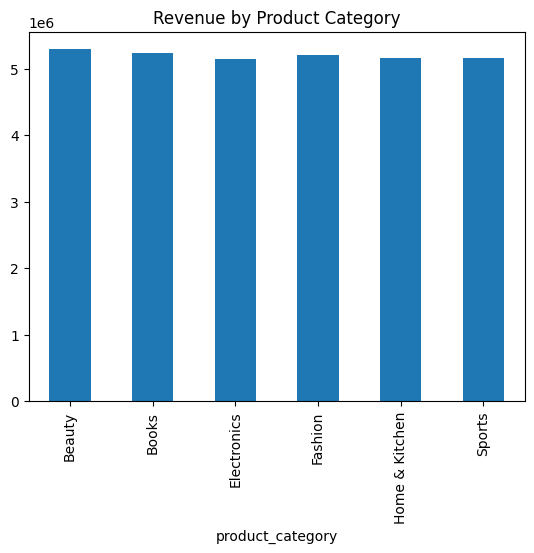

In [53]:
category_sales = df_clean.groupby('product_category')['total_revenue'].sum()

category_sales.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.show()

In [ ]:
Some product categories generate significantly higher revenue than others. These categories represent the most profitable segments and should be prioritized for marketing and inventory management.

## Region wise sales

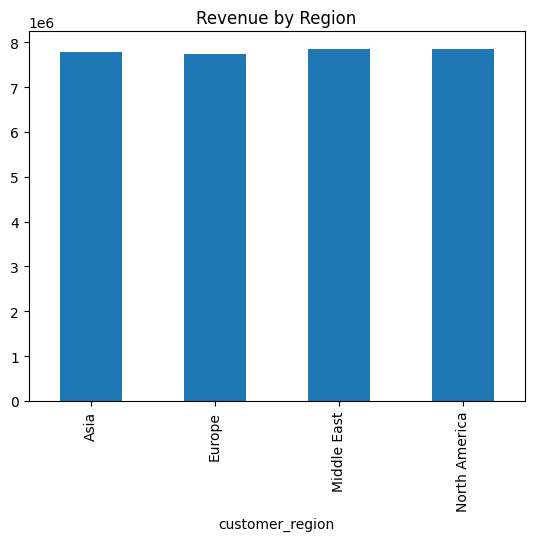

In [55]:
region_sales = df_clean.groupby('customer_region')['total_revenue'].sum()

region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.show()

In [ ]:
Revenue varies across customer regions, indicating differences in demand and purchasing behavior. Regions with higher revenue contribute significantly to overall sales performance.

## Payment method Analysis

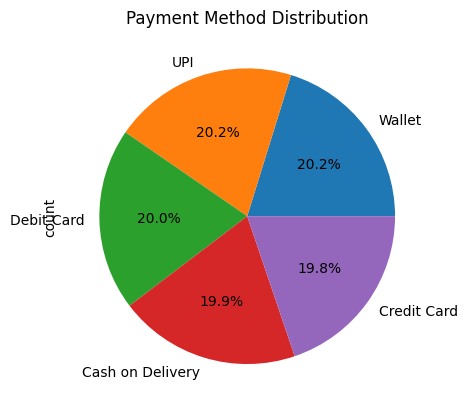

In [57]:
df_clean['payment_method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

In [ ]:
The payment method distribution shows that customers prefer certain payment methods more than others. Businesses should optimize checkout experiences for the most commonly used payment options.

## Monthly Sales trend Analysis

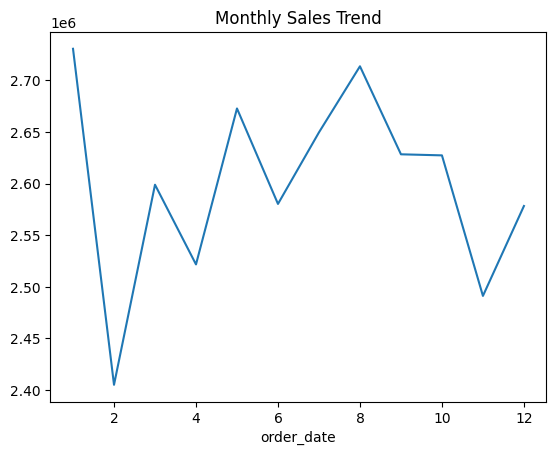

In [62]:
df_clean.loc[:,'order_date'] = pd.to_datetime(df_clean['order_date'])

df_clean.groupby(df_clean['order_date'].dt.month)['total_revenue'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()


# This step converts the order_date column from text format to datetime format so that we can perform time-based analysis such as monthly or yearly sales trends.

In [ ]:
Monthly sales trends indicate that sales fluctuate over time, suggesting the presence of seasonal demand patterns. Businesses can use this information to plan promotions and inventory management.

## Conclusion

In [ ]:
The exploratory data analysis of the Amazon sales dataset revealed several important insights. Total revenue is mainly influenced by product price and quantity sold. Certain product categories and customer regions contribute significantly to overall revenue. Customer payment preferences show a strong inclination toward specific payment methods. Additionally, monthly sales trends indicate potential seasonal variations in demand. These insights can help businesses optimize pricing strategies, marketing efforts, and inventory management to improve overall sales performance.